
FIRST 5 ROWS:

              datetime  season  rainfall_mm  humidity  temperature  \
0  2024-01-01 00:00:00  Winter           38        46           27   
1  2024-01-01 01:00:00  Winter            6        45           15   
2  2024-01-01 02:00:00  Winter           16        65           27   
3  2024-01-01 03:00:00  Winter           27        73           28   
4  2024-01-01 04:00:00  Winter           38        41           15   

   tank_capacity  water_level  daily_usage  occupancy  roof_area  \
0           2000         1958          334          4        194   
1           1000          776          316          3         86   
2           2000          634          230         11         60   
3           1500         1369          110          4         70   
4           1500          438          162         10        195   

   collection_efficiency  water_collected  overflow_risk  leakage_detected  \
0                   0.61           449.69              1                 0  

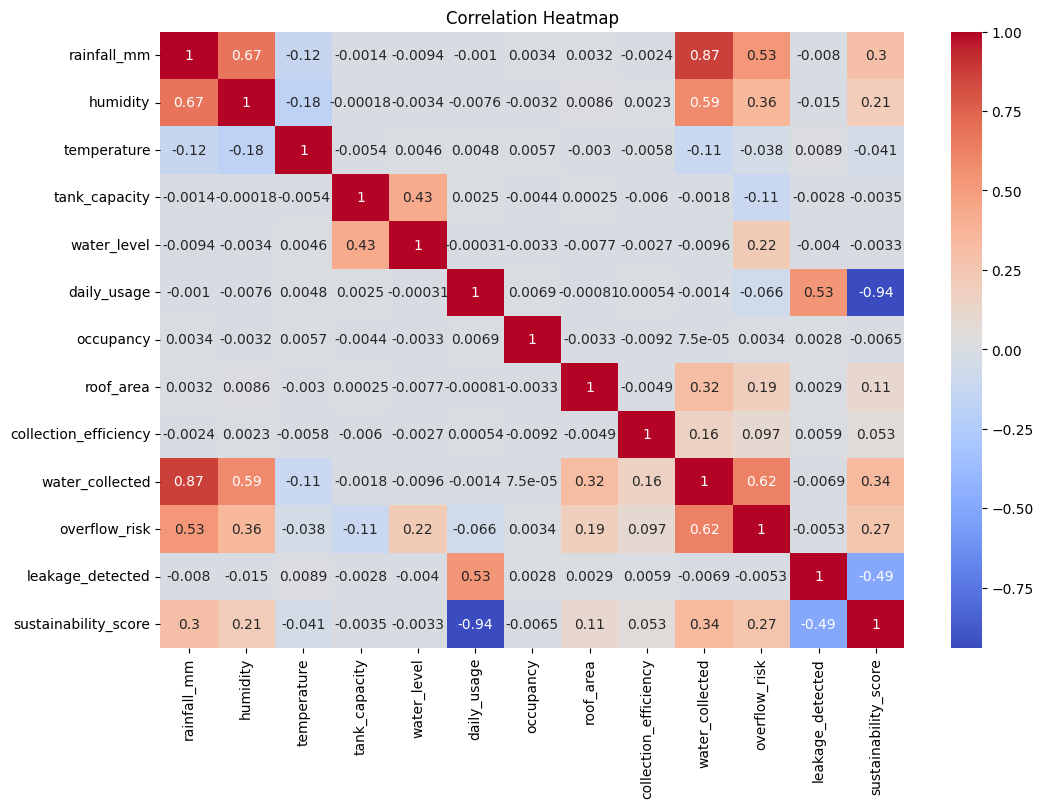

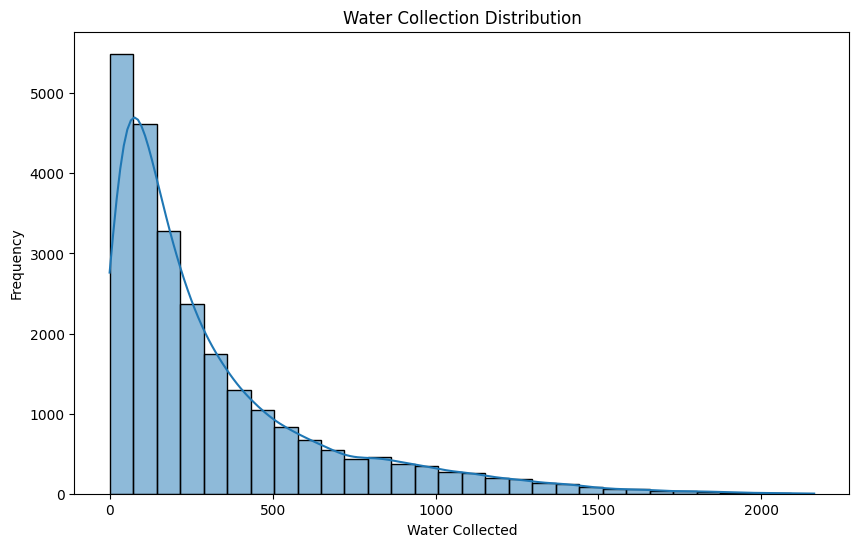

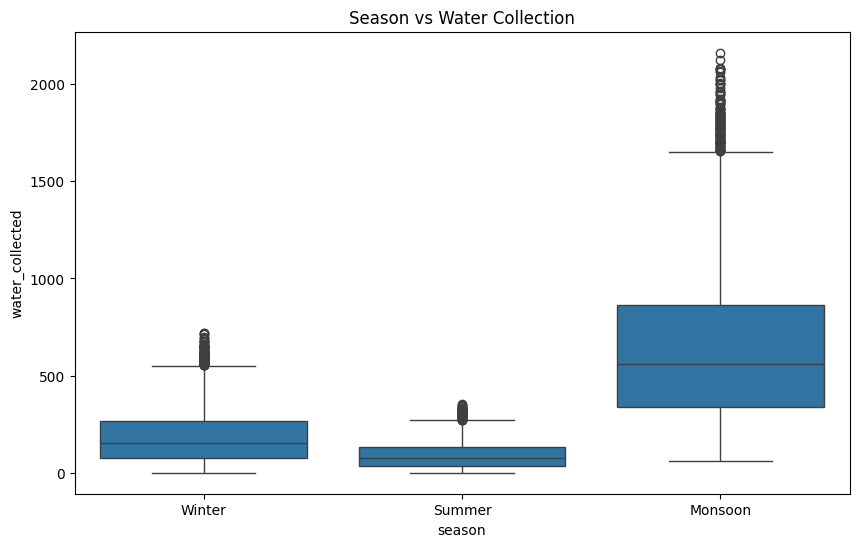

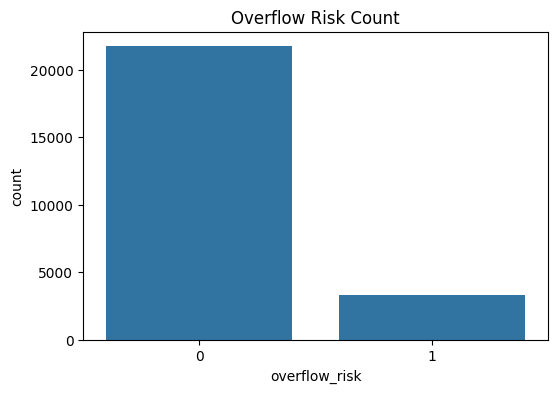

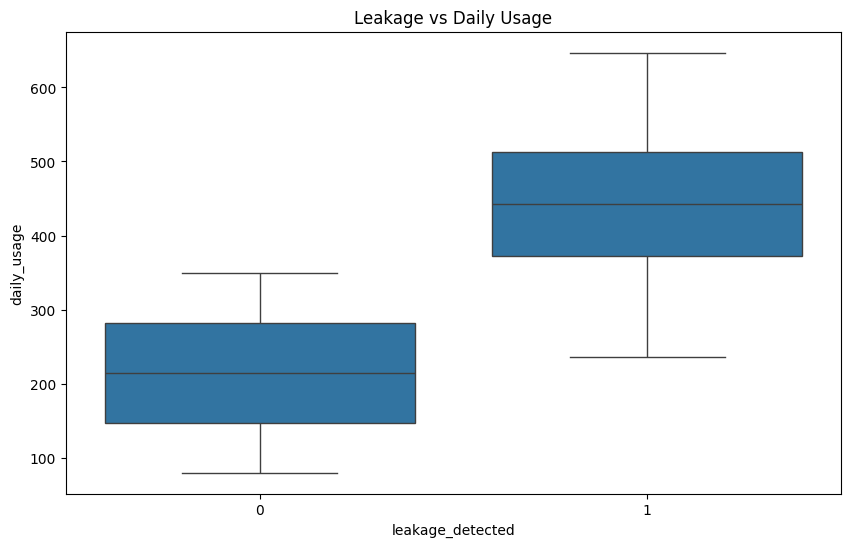

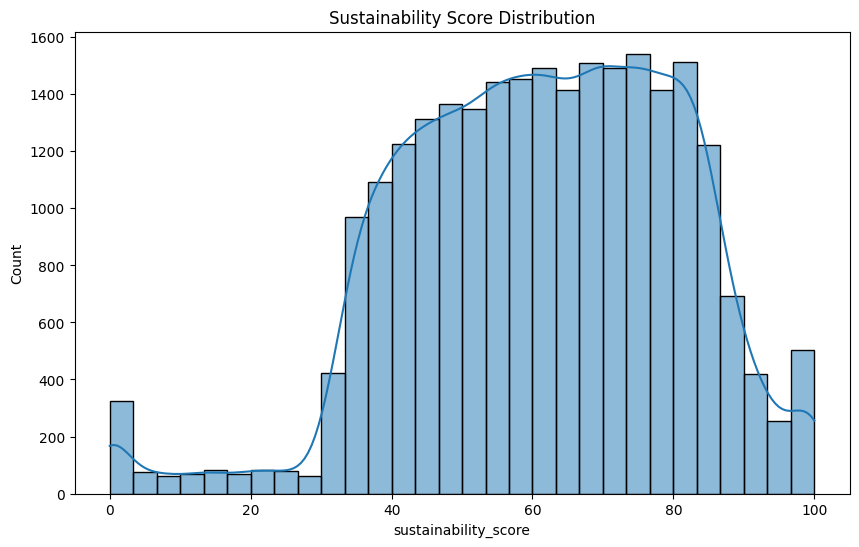

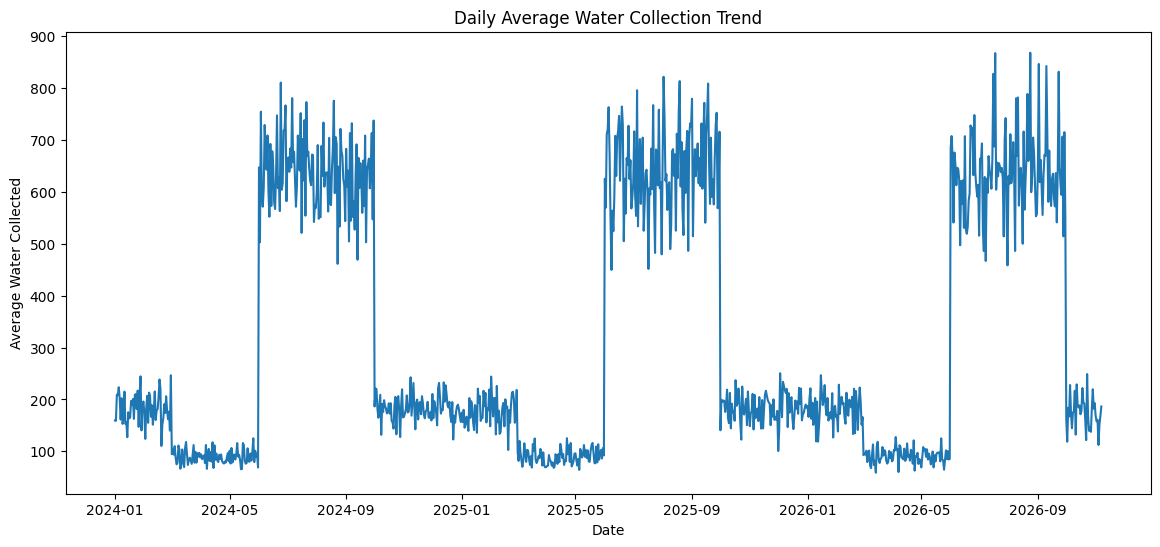


EDA COMPLETED SUCCESSFULLY!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv(
    "data/smart_water_dataset.csv"
)

# -----------------------------
# BASIC INFO
# -----------------------------

print("\nFIRST 5 ROWS:\n")
print(df.head())

print("\nDATASET INFO:\n")
print(df.info())

print("\nSTATISTICS:\n")
print(df.describe())

# -----------------------------
# MISSING VALUES
# -----------------------------

print("\nMISSING VALUES:\n")
print(df.isnull().sum())

# -----------------------------
# CONVERT DATETIME
# -----------------------------

df["datetime"] = pd.to_datetime(
    df["datetime"]
)

# -----------------------------
# CORRELATION HEATMAP
# -----------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# -----------------------------
# WATER COLLECTION DISTRIBUTION
# -----------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["water_collected"],
    bins=30,
    kde=True
)

plt.title(
    "Water Collection Distribution"
)

plt.xlabel("Water Collected")

plt.ylabel("Frequency")

plt.show()

# -----------------------------
# SEASONAL ANALYSIS
# -----------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="season",
    y="water_collected",
    data=df
)

plt.title(
    "Season vs Water Collection"
)

plt.show()

# -----------------------------
# OVERFLOW RISK COUNT
# -----------------------------

plt.figure(figsize=(6, 4))

sns.countplot(
    x="overflow_risk",
    data=df
)

plt.title("Overflow Risk Count")

plt.show()

# -----------------------------
# LEAKAGE ANALYSIS
# -----------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="leakage_detected",
    y="daily_usage",
    data=df
)

plt.title(
    "Leakage vs Daily Usage"
)

plt.show()

# -----------------------------
# SUSTAINABILITY SCORE
# -----------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["sustainability_score"],
    bins=30,
    kde=True
)

plt.title(
    "Sustainability Score Distribution"
)

plt.show()

# -----------------------------
# TIME SERIES TREND
# -----------------------------

daily_trend = df.groupby(
    df["datetime"].dt.date
)["water_collected"].mean()

plt.figure(figsize=(14, 6))

plt.plot(daily_trend)

plt.title(
    "Daily Average Water Collection Trend"
)

plt.xlabel("Date")

plt.ylabel("Average Water Collected")

plt.show()

print("\nEDA COMPLETED SUCCESSFULLY!")